In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from lightgbm import LGBMRegressor
import shap

sns.set_theme()

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)

Shape inicial: (1678326, 48)


In [7]:
df = df.drop(columns=[
    'id','pesid','id_veiculo',
    'mortos','feridos_leves','feridos_graves',
    'total_vitimas','gravidade_numerica','estado_fisico','ilesos',
    'Modelo_Grupo','uop','delegacia','regional'
])

print("Shape após drop:", df.shape)

Shape após drop: (1678326, 34)


In [8]:
mapping = {
    'Sem Vítimas': 0,
    'Com Vítimas Feridas': 1,
    'Com Vítimas Fatais': 1
}

df['severity_binary'] = df['classificacao_acidente'].map(mapping)

df = df.dropna(subset=['severity_binary'])

In [9]:
df = df.dropna(subset=['latitude','longitude','km'])

In [10]:
df['ano_fabricacao_veiculo'] = df['ano_fabricacao_veiculo'].fillna(
    df['ano_fabricacao_veiculo'].median()
)

In [11]:
df['latitude'] = (
    df['latitude']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df['longitude'] = (
    df['longitude']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [13]:
df['data_inversa'] = pd.to_datetime(
    df['data_inversa'],
    errors='coerce',
    dayfirst=True
)

In [14]:
df['hora'] = pd.to_datetime(df['horario'], errors='coerce').dt.hour
df['mes'] = df['data_inversa'].dt.month
df['dia_semana'] = df['data_inversa'].dt.dayofweek

C:\Users\fause\AppData\Local\Temp\ipykernel_17828\3316088481.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora'] = pd.to_datetime(df['horario'], errors='coerce').dt.hour


In [15]:
coords = df[['latitude','longitude']]

sample_coords = coords.sample(200000, random_state=42)

kmeans = KMeans(n_clusters=40, random_state=42, n_init=10)
kmeans.fit(sample_coords)

df['cluster_regiao'] = kmeans.predict(coords)

In [17]:
df['km'] = (
    df['km']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['km'] = pd.to_numeric(df['km'], errors='coerce')

In [18]:
df['ano_fabricacao_veiculo'] = pd.to_numeric(
    df['ano_fabricacao_veiculo'],
    errors='coerce'
)

In [19]:
df['hora'] = pd.to_numeric(df['hora'], errors='coerce')
df['mes'] = pd.to_numeric(df['mes'], errors='coerce')

In [20]:
df = df.dropna(subset=[
    'km',
    'ano_fabricacao_veiculo',
    'hora',
    'mes'
])

In [21]:
df_risk = (
    df
    .groupby('cluster_regiao')
    .agg(
        total_acidentes=('severity_binary','count'),
        taxa_vitima=('severity_binary','mean'),
        km_medio=('km','mean'),
        hora_media=('hora','mean'),
        mes_medio=('mes','mean'),
        ano_veiculo_medio=('ano_fabricacao_veiculo','mean')
    )
    .reset_index()
)

print("Shape dataset risco:", df_risk.shape)

Shape dataset risco: (40, 7)


In [22]:
features = [
    'total_acidentes',
    'km_medio',
    'hora_media',
    'mes_medio',
    'ano_veiculo_medio'
]

X = df_risk[features]
y = df_risk['taxa_vitima']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred, squared=False))

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 32, number of used features: 0
[LightGBM] [Info] Start training from score 0.882802
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spli

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='bar')
plt.title("Importância das Variáveis - Modelo Espacial")
plt.show()

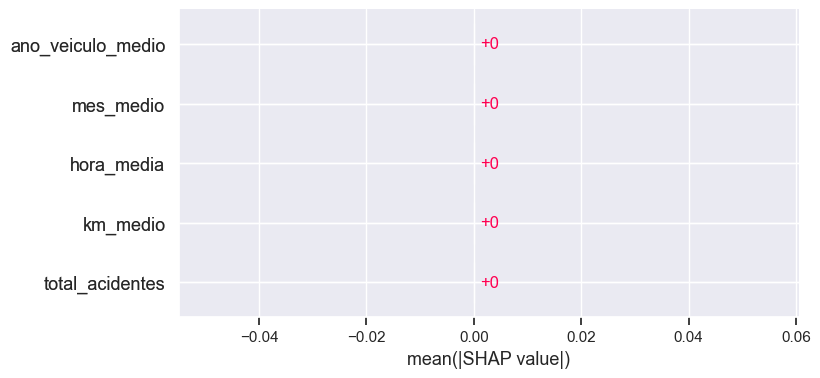

In [25]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

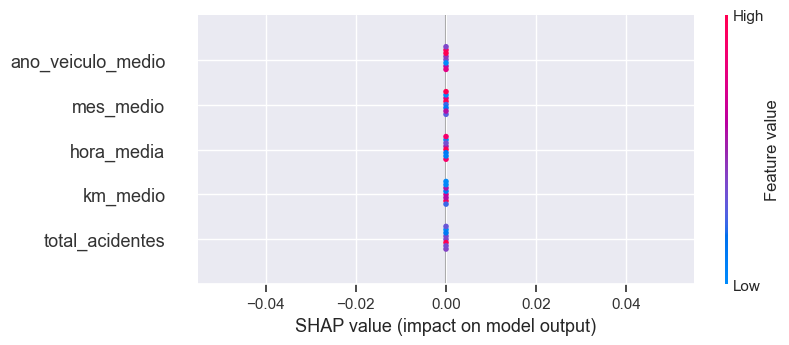

In [26]:
shap.plots.beeswarm(shap_values)